In [1]:
!pip install opencv-python numpy
%pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Disblay image

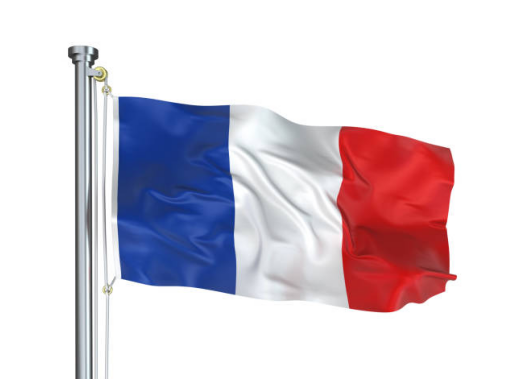

In [2]:
import cv2
from matplotlib import pyplot as plt

image = cv2.imread("flag.jpg")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

In [3]:
import cv2
import numpy as np

img = cv2.imread("flag.jpg")
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

colors = {
    "Red": ([0,120,70], [10,255,255]),
    "Green": ([40,40,40], [80,255,255]),
    "Blue": ([100,150,0], [140,255,255]),
    "Yellow": ([20,100,100], [30,255,255])
}

for color_name, (lower, upper) in colors.items():
    lower = np.array(lower)
    upper = np.array(upper)

    mask = cv2.inRange(hsv, lower, upper)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        if cv2.contourArea(cnt) > 500:
            x, y, w, h = cv2.boundingRect(cnt)

            cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)
            cv2.putText(img, color_name, (x + 10, y + 30),
            cv2.FONT_HERSHEY_SIMPLEX, 1,
            (255, 255, 255), 2)

cv2.imshow("Color Recognition", img)
cv2.waitKey(0)
cv2.destroyAllWindows()